In this notebook, we consider the results for the rational quadratic correlation function.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import torch
import scipy
import scipy.linalg
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process

In [2]:
# crossing_type = "upcrossing"  
# crossing_type = "downcrossing"
crossing_type = "crossing"
ModelClass = formula.GaussianUpCrossingsDimless

mean_rate_method = f"{crossing_type}_mean_rate"
fano_method = f"{crossing_type}_fano_factor_CLT"

In [3]:
# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
alpha = 3/2  # Shape parameter controlling the relative weighting of different scales
sigma = 1.0 # Standard deviation (amplitude) of the process

In [4]:
num_points_taus = 50
taus = torch.linspace(0.01, 1.0, num_points_taus)

num_points_psi = 50
psi = torch.linspace(0.0, 3.0, num_points_psi)

mean_rates = torch.zeros(num_points_taus, num_points_psi)
fano_factors = torch.zeros(num_points_taus, num_points_psi)

In [5]:
for i in range(num_points_taus):
    for j in range(num_points_psi):
        u = psi[j] * sigma
        tau = taus[i]
        model = ModelClass(r_func=process.r_rational_quadratic, u=u, tau=tau, sigma=sigma, alpha=alpha)
        mean_rates[i, j] = getattr(model, mean_rate_method)()
        fano_factors[i, j] = getattr(model, fano_method)(epsilon_left=1e-2, epsilon_right=1e-5)

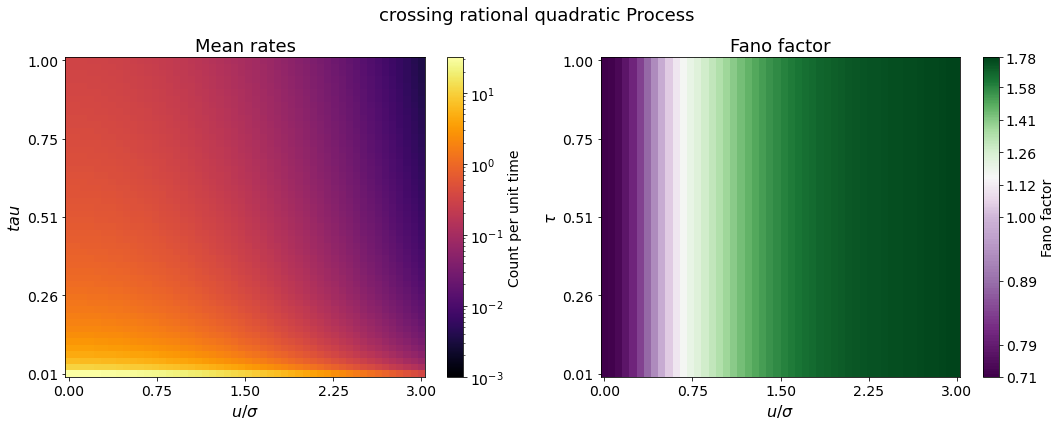

In [6]:
# -----------------------
# Plotting parameters
# -----------------------
cmap_mean = 'inferno'
cmap_fano = 'PRGn'
label_fontsize = 16
tick_fontsize = 14
title_fontsize = 18
cbar_labelsize = 14

# Number of ticks to display on each axis (independent of underlying spacing)
num_ticks = 5
x_ticks = np.linspace(psi.min(), psi.max(), num_ticks)
y_ticks = np.linspace(taus.min(), taus.max(), num_ticks)

# -----------------------
# Create the figure and subplots

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- Left subplot: Mean Rates with Linear Scale ----
# Set a small threshold epsilon for the lower bound (adjust as needed)
epsilon = 1e-3
# Clip the data so that no value is below epsilon
adjusted_mean_rates = np.clip(mean_rates, epsilon, None)
# Set up LogNorm with vmin set to epsilon and vmax as the maximum of the adjusted data
log_norm = LogNorm(vmin=epsilon, vmax=adjusted_mean_rates.max())

pc0 = axes[0].pcolormesh(psi, taus, adjusted_mean_rates, shading='auto',
                         cmap=cmap_mean, norm=log_norm)
cbar0 = fig.colorbar(pc0, ax=axes[0])
cbar0.set_label("Count per unit time", fontsize=cbar_labelsize)
cbar0.ax.tick_params(labelsize=tick_fontsize)

axes[0].set_xlabel(r'$u/\sigma$', fontsize=label_fontsize)
axes[0].set_ylabel(r'$tau$', fontsize=label_fontsize)
axes[0].set_title('Mean rates', fontsize=title_fontsize)
axes[0].set_xticks(x_ticks)
axes[0].set_yticks(y_ticks)
axes[0].set_xticklabels([f"{val:.2f}" for val in x_ticks], fontsize=tick_fontsize)
axes[0].set_yticklabels([f"{val:.2f}" for val in y_ticks], fontsize=tick_fontsize)

# -----------------------
# Right subplot: Fano Factors
# -----------------------
# Plot Fano factors on a linear scale
fano_log = np.log10(fano_factors)

# Use the custom normalization, setting the midpoint at 0 (log10(1))
norm_fano = utils.MidpointNormalize(vmin=fano_log.min(), vmax=fano_log.max(), midpoint=0)

pc1 = axes[1].pcolormesh(psi, taus, fano_log, shading='auto',
                         cmap=cmap_fano, norm=norm_fano)
cbar1 = fig.colorbar(pc1, ax=axes[1])
cbar1.set_label("Fano factor", fontsize=cbar_labelsize)
cbar1.ax.tick_params(labelsize=tick_fontsize)

# Adjust colorbar tick labels to show original Fano factor values.
def log_tick_formatter(x, pos):
    return f"{10**x:.2f}"
cbar1.formatter = mticker.FuncFormatter(log_tick_formatter)
cbar1.update_ticks()

axes[1].set_xlabel(r'$u/\sigma$', fontsize=label_fontsize)
axes[1].set_ylabel(r'$\tau$', fontsize=label_fontsize)
axes[1].set_title('Fano factor', fontsize=title_fontsize)
axes[1].set_xticks(x_ticks)
axes[1].set_yticks(y_ticks)
axes[1].set_xticklabels([f"{val:.2f}" for val in x_ticks], fontsize=tick_fontsize)
axes[1].set_yticklabels([f"{val:.2f}" for val in y_ticks], fontsize=tick_fontsize)

# in title for both plots add crossing type
fig.suptitle(f"{crossing_type} rational quadratic Process", fontsize=title_fontsize)

plt.tight_layout()
plt.show()

In [7]:
model = ModelClass(r_func=process.r_rational_quadratic, u=1.0, tau=0.01, sigma=sigma, alpha=alpha)
print(getattr(model, fano_method)(epsilon_left=1e-2, epsilon_right=1e-5))

tensor(1.2402)


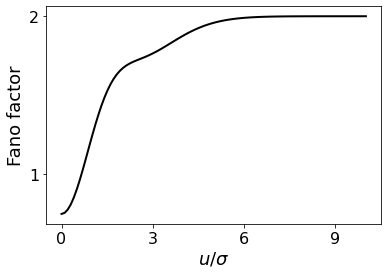

In [8]:
# plotting the fano factor curve as a function of u for any tau
sigma = 1.0
alpha = 3/2

psi = torch.linspace(0.0, 10.0, 100)
fano_factors = torch.zeros_like(psi)
for i in range(len(psi)):
    model = ModelClass(r_func=process.r_rational_quadratic, u=psi[i] * sigma, tau=1.0, sigma=sigma, alpha=alpha)
    fano_factors[i] = getattr(model, fano_method)()

plt.plot(psi, fano_factors, linewidth=2, color='k')

plt.xlabel(r'$u/\sigma$', fontsize=18)
plt.ylabel('Fano factor', fontsize=18)

ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=16)

max_xticks = 5  # Maximum number of tick intervals on x-axis
max_yticks = 5  # Maximum number of tick intervals on y-axis
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=max_xticks, integer=True))
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=max_yticks, integer=True))
plt.show()

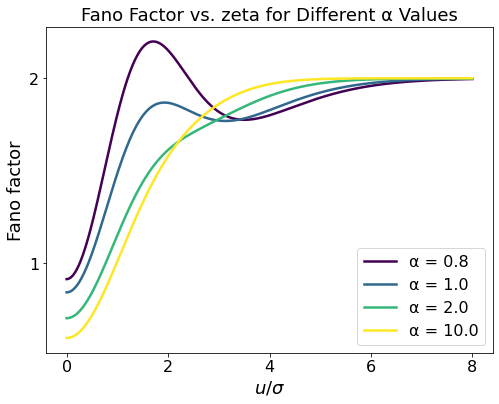

In [9]:
# fano factor vs psi for different alpha values

# Define the range for psi and the different alpha values
psi = torch.linspace(0.0, 8.0, 500)
alpha_values = [0.8, 1.0, 2.0, 10.0]  # You can specify any number of alpha values

# Create a discrete colormap using viridis
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, len(alpha_values)))

plt.figure(figsize=(8, 6))
for idx, alpha in enumerate(alpha_values):
    fano_factors = torch.zeros_like(psi)
    for i in range(len(psi)):
        model = ModelClass(
            r_func=process.r_rational_quadratic,
            u=psi[i] * sigma,
            tau=1.0,
            sigma=sigma,
            alpha=alpha
        )
        fano_factors[i] = getattr(model, fano_method)()
    plt.plot(psi.numpy(), fano_factors.numpy(), linewidth=2.5,
             color=colors[idx], label=f'α = {alpha}')

# Set font sizes for labels and title
plt.xlabel(r'$u/\sigma$', fontsize=18)
plt.ylabel('Fano factor', fontsize=18)
plt.title('Fano Factor vs. psi for Different α Values', fontsize=18)
plt.legend(fontsize=16)

# Get the current axis and update tick parameters
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=16)

# Control the number of ticks on x and y axes:
max_xticks = 5  # Maximum number of tick intervals on x-axis
max_yticks = 5  # Maximum number of tick intervals on y-axis
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=max_xticks, integer=True))
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=max_yticks, integer=True))

plt.show()